In [2]:
import tensorflow as tf

print("Версия TensorFlow:", tf.__version__)
print("Доступные GPU:", tf.config.list_physical_devices('GPU'))
print("Устройство для вычислений:", tf.test.is_gpu_available())

Версия TensorFlow: 2.14.0
Доступные GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Устройство для вычислений: True


2026-04-06 20:07:17.972588: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-06 20:07:17.973964: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-06 20:07:17.975132: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ddosad/dummy-truck-sales-for-time-series")

print("Path to dataset files:", path)

Path to dataset files: /home/nikita/.cache/kagglehub/datasets/ddosad/dummy-truck-sales-for-time-series/versions/1


In [4]:
import os

os.listdir(path)

['Truck_sales.csv']

In [5]:
import pandas as pd
import numpy as np

df_pre = pd.read_csv(path + '/Truck_sales.csv')

In [6]:
df_pre

,Month-Year,Number_Trucks_Sold
0,03-Jan,155
1,03-Feb,173
2,03-Mar,204
3,03-Apr,219
4,03-May,223
...,...,...
139,14-Aug,933
140,14-Sep,704
141,14-Oct,639
142,14-Nov,571


In [7]:
df = df_pre

df['year'] = df['Month-Year'].str[:2].astype(int)
df['month'] = df['Month-Year'].str[3:7].map({'Jan':1,'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 
                                             'Jun':6, 'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12}).astype(int)

df['Number_Trucks_Sold'] = df['Number_Trucks_Sold'] / 100

len_split = 25

df['lag_1'] = df['Number_Trucks_Sold'].shift(1).fillna(0)
for i in range(2, len_split):
    df[f'lag_{i}'] = df[f'lag_{i-1}'].shift(1).fillna(0)

df

,Month-Year,Number_Trucks_Sold,year,month,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24
0,03-Jan,1.55,3,1,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,03-Feb,1.73,3,2,1.55,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,03-Mar,2.04,3,3,1.73,1.55,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,03-Apr,2.19,3,4,2.04,1.73,1.55,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,03-May,2.23,3,5,2.19,2.04,1.73,1.55,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,14-Aug,9.33,14,8,9.58,8.24,8.72,7.81,6.46,5.72,...,7.77,6.71,6.25,5.01,4.99,5.19,4.53,4.97,5.60,7.78
140,14-Sep,7.04,14,9,9.33,9.58,8.24,8.72,7.81,6.46,...,7.27,7.77,6.71,6.25,5.01,4.99,5.19,4.53,4.97,5.60
141,14-Oct,6.39,14,10,7.04,9.33,9.58,8.24,8.72,7.81,...,8.44,7.27,7.77,6.71,6.25,5.01,4.99,5.19,4.53,4.97
142,14-Nov,5.71,14,11,6.39,7.04,9.33,9.58,8.24,8.72,...,8.61,8.44,7.27,7.77,6.71,6.25,5.01,4.99,5.19,4.53


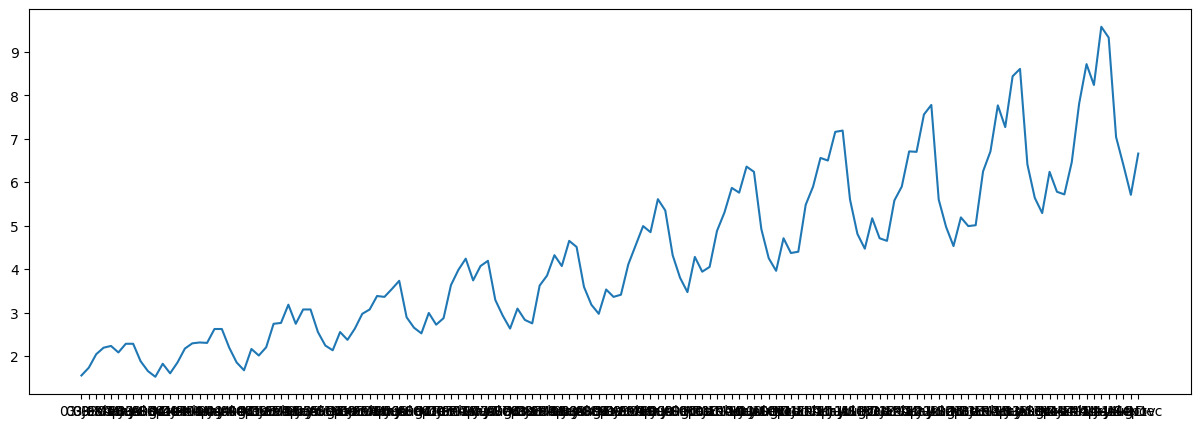

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['Month-Year'], df['Number_Trucks_Sold'])
plt.show()

In [9]:
import seaborn as seaborn

df = df.drop(['Month-Year'], axis = 1)

# plt.figure(figsize=(6, 6))
# seaborn.heatmap(df.corr(), annot=True, cmap='seismic', center=0)
# plt.title('Parameter correlation graph')
# plt.show()

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(['Number_Trucks_Sold'], axis = 1)
y = df['Number_Trucks_Sold']

X = X.to_numpy()
y = y.to_numpy()

X = X[25:]
y = y[25:]

X = X.reshape((X.shape[0], X.shape[1], 1))

In [29]:
from sklearn.model_selection import train_test_split

# X = df.drop(['Number_Trucks_Sold'], axis = 1)
# y = df['Number_Trucks_Sold']

# X = X.to_numpy()
# X = X[20:]
# X = X.reshape((X.shape[0], X.shape[1], 1))

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.10, shuffle=False)

In [30]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

In [34]:
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import EarlyStopping

model = keras.Sequential([
    keras.layers.GRU(32, return_sequences=False, activation='tanh', input_shape=(x_train.shape[1], x_train.shape[2])),
    keras.layers.Dense(1)
])

# model.summary()


model.compile(  optimizer = keras.optimizers.Adam(learning_rate = 3e-4),#3e-4
                loss = 'mse',
                metrics = ['R2Score']
                )

early_stopping = EarlyStopping(
                    monitor='val_r2_score',
                    patience = 20,
                    min_delta = 0.001,
                    verbose = 0,
                    restore_best_weights = True,
                    mode = 'max'
                    )

model.fit(
        x = x_train,
        y = y_train,
        batch_size = 1,
        epochs = 2000,
        verbose = 0,
        callbacks = [early_stopping], 
        shuffle = False,
        validation_split=0,
        validation_data = (x_test, y_test),
        validation_batch_size = 1
        )

train_loss, keras_train_r2 = model.evaluate(x_train, y_train)
test_loss, keras_test_r2 = model.evaluate(x_test, y_test)
print('\nдля нейронной сети R^2 метрика для обучающей \ тестовой выборки:', keras_train_r2, ' \ ', keras_test_r2)

1/1 [==============================] - 0s 18ms/step - loss: 0.7171 - r2_score: 0.6057

для нейронной сети R^2 метрика для обучающей \ тестовой выборки: 0.9639519453048706  \  0.6056983470916748


In [35]:
def model_predict(model, x_train, y_train, x_test, y_test):

    cols = ['Number_Trucks_Sold']

    try:
        train_loss, keras_train_r2 = model.evaluate(x_train, y_train)
        test_loss, keras_test_r2 = model.evaluate(x_test, y_test)
    except AttributeError:
        keras_train_r2 = model.score(x_train, y_train)
        keras_test_r2 = model.score(x_test, y_test)

    fact = y_train
    predict = model.predict(x_test)

    # for i in range(len(y_test)):
    #     print('predict :', predict[i],'\ttrue', y_test[i], '\tdiff, %', (y_test[i]/predict[i] - 1)*100)

    # print('----------------')
    # print('min \ max diff in %:', min( [ min(j) for j in [(y_test[i]/predict[i] - 1)*100 for i in range(len(y_test))] ])
    #       , ' \ ', max( [ max(j) for j in [(y_test[i]/predict[i] - 1)*100 for i in range(len(y_test))] ]))
    print('----------------')
    
    print('R^2 метрика для обучающей \ тестовой выборки:', keras_train_r2, ' \ ', keras_test_r2)
    print('----------------')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(range(len(fact)), fact, color='blue', label='fact')
    ax1.plot(range(len(fact), len(fact) + len(predict)), predict, color='red', label='predict')
    ax1.axvline(x=len(fact) - 1, color='green', linestyle='--', linewidth=2, label='Граница')
    ax1.set_title(cols)
    ax1.legend()

    ax2.plot(range(len(predict)), y_test, label="Test")
    ax2.plot(range(len(predict)), predict, label="predict")
    ax2.set_title('test vs predict')
    ax2.legend()

    plt.tight_layout()
    plt.show()

1/1 [==============================] - 0s 145ms/step
----------------
R^2 метрика для обучающей \ тестовой выборки: 0.9639519453048706  \  0.6056983470916748
----------------


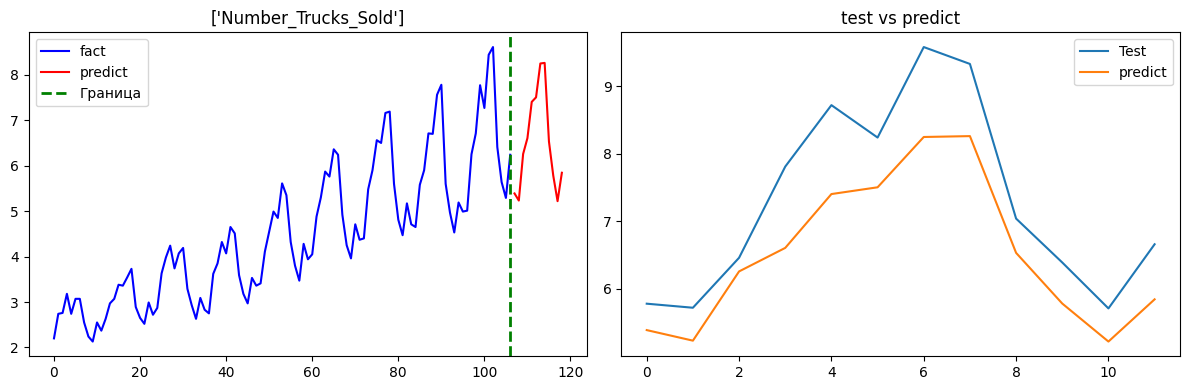

In [36]:
model_predict(model, x_train, y_train, x_test, y_test)

In [37]:
model_lstm = keras.Sequential([
    keras.layers.LSTM(32, return_sequences=False, input_shape=(x_train.shape[1], x_train.shape[2])),
    keras.layers.Dense(1)
])

# model.summary()


model_lstm.compile(  optimizer = keras.optimizers.Adam(learning_rate = 3e-4),#3e-4
                loss = 'mse',
                metrics = ['R2Score']
                )

early_stopping = EarlyStopping(
                    monitor='val_r2_score',
                    patience = 20,
                    min_delta = 0.001,
                    verbose = 0,
                    restore_best_weights = True,
                    mode = 'max'
                    )

model_lstm.fit(
        x = x_train,
        y = y_train,
        batch_size = 1,
        epochs = 2000,
        verbose = 0,
        callbacks = [early_stopping], 
        shuffle = False,
        validation_split=0,
        validation_data = (x_test, y_test),
        validation_batch_size = 1
        )

train_loss, keras_train_r2 = model_lstm.evaluate(x_train, y_train)
test_loss, keras_test_r2 = model_lstm.evaluate(x_test, y_test)
print('\nдля нейронной сети R^2 метрика для обучающей \ тестовой выборки:', keras_train_r2, ' \ ', keras_test_r2)

1/1 [==============================] - 0s 16ms/step - loss: 0.3467 - r2_score: 0.8094

для нейронной сети R^2 метрика для обучающей \ тестовой выборки: 0.9892141819000244  \  0.809351921081543


1/1 [==============================] - 0s 180ms/step
----------------
R^2 метрика для обучающей \ тестовой выборки: 0.9892141819000244  \  0.809351921081543
----------------


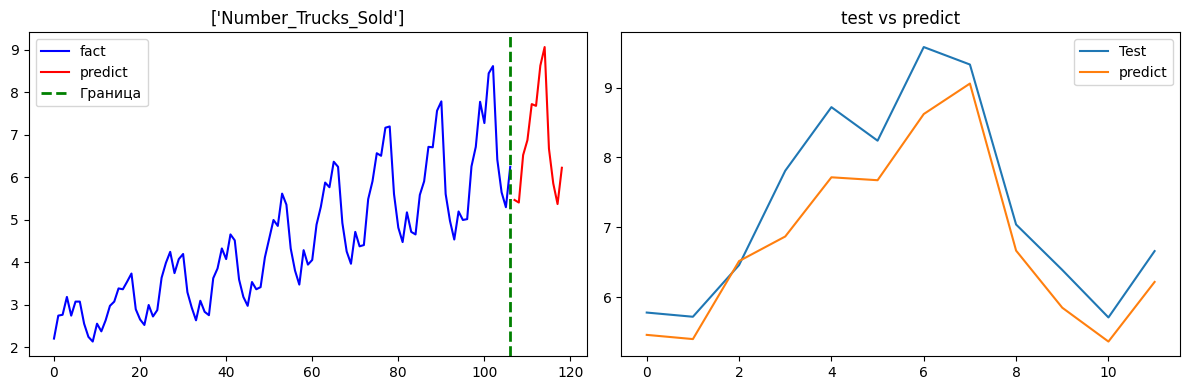

In [38]:
model_predict(model_lstm, x_train, y_train, x_test, y_test)

In [61]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score

x_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) 
x_test_t  = torch.tensor(x_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

class SimpleRNNCell(nn.Module):
    
    #h_t = tanh(W_ih x_t + b_ih + W_hh h_{t-1} + b_hh)
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.W_ih = nn.Parameter(torch.randn(hidden_size, input_size) * 0.01)
        self.b_ih = nn.Parameter(torch.zeros(hidden_size))
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_hh = nn.Parameter(torch.zeros(hidden_size))
        self.tanh = nn.Tanh()

    def forward(self, x, h_prev):
        # x: (batch, input_size)
        # h_prev: (batch, hidden_size)
        h = self.tanh(x @ self.W_ih.t() + self.b_ih + h_prev @ self.W_hh.t() + self.b_hh)
        return h

class ManualRNN(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.cell = SimpleRNNCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.cell.hidden_size, device=x.device)
        for t in range(seq_len):
            h = self.cell(x[:, t, :], h)
        out = self.fc(h)
        return out

def train_model(model, x_train, y_train, x_val, y_val,
                lr=3e-4, epochs=2000, patience=20, min_delta=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_r2 = -np.inf
    best_state_dict = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for i in range(len(x_train)):
            x_i = x_train[i:i+1]   # (1, seq_len, features)
            y_i = y_train[i:i+1]   # (1, 1)
            optimizer.zero_grad()
            y_pred = model(x_i)
            loss = criterion(y_pred, y_i)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(x_train)

        model.eval()
        with torch.no_grad():
            y_pred_train = model(x_train).numpy()
            y_pred_val   = model(x_val).numpy()
            train_r2 = r2_score(y_train.numpy(), y_pred_train)
            val_r2   = r2_score(y_val.numpy(),   y_pred_val)

        # Ранняя остановка по val_r2
        if val_r2 > best_val_r2 + min_delta:
            best_val_r2 = val_r2
            best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1} (val_r2 = {val_r2:.4f})")
            break

        if (epoch+1) % 20 == 0:
            print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.6f}, train_r2={train_r2:.4f}, val_r2={val_r2:.4f}")

    model.load_state_dict(best_state_dict)
    return model



In [62]:
rnn_model = ManualRNN(input_size=1, hidden_size=32, output_size=1)
rnn_model = train_model(rnn_model, x_train_t, y_train_t, x_test_t, y_test_t)

rnn_model.eval()
with torch.no_grad():
    train_pred = rnn_model(x_train_t).numpy()
    test_pred  = rnn_model(x_test_t).numpy()
    train_r2 = r2_score(y_train, train_pred)
    test_r2  = r2_score(y_test,  test_pred)
print(f"\nRNN: R^2 train = {train_r2:.4f}, R^2 test = {test_r2:.4f}")

Epoch 20: train_loss=0.703872, train_r2=0.5524, val_r2=-0.6466
Epoch 40: train_loss=0.187098, train_r2=0.9348, val_r2=0.3357
Epoch 60: train_loss=0.142173, train_r2=0.9471, val_r2=0.4959
Epoch 80: train_loss=0.134207, train_r2=0.9482, val_r2=0.5380
Epoch 100: train_loss=0.129718, train_r2=0.9498, val_r2=0.5594
Epoch 120: train_loss=0.125083, train_r2=0.9524, val_r2=0.5811
Epoch 140: train_loss=0.121179, train_r2=0.9548, val_r2=0.6052
Epoch 160: train_loss=0.117946, train_r2=0.9566, val_r2=0.6280
Epoch 180: train_loss=0.114513, train_r2=0.9582, val_r2=0.6478
Epoch 200: train_loss=0.110029, train_r2=0.9560, val_r2=0.6672
Epoch 220: train_loss=0.107629, train_r2=0.9566, val_r2=0.6524
Early stopping at epoch 223 (val_r2 = 0.6516)

RNN: R^2 train = 0.9547, R^2 test = 0.6684


In [63]:
def model_predict_pytorch(model, x_train, y_train, x_test, y_test, device=None):

    if device is None:
        device = next(model.parameters()).device

    if not torch.is_tensor(x_train):
        x_train = torch.tensor(x_train, dtype=torch.float32)
        y_train = torch.tensor(y_train, dtype=torch.float32)
        x_test  = torch.tensor(x_test, dtype=torch.float32)
        y_test  = torch.tensor(y_test, dtype=torch.float32)

    if y_train.dim() == 1:
        y_train = y_train.view(-1, 1)
    if y_test.dim() == 1:
        y_test = y_test.view(-1, 1)

    x_train = x_train.to(device)
    y_train = y_train.to(device)
    x_test  = x_test.to(device)
    y_test  = y_test.to(device)

    model.eval()
    with torch.no_grad():
        pred_train = model(x_train).cpu().numpy()
        pred_test  = model(x_test).cpu().numpy()
        y_train_np = y_train.cpu().numpy()
        y_test_np  = y_test.cpu().numpy()

        criterion = torch.nn.MSELoss()
        train_loss = criterion(torch.tensor(pred_train), torch.tensor(y_train_np)).item()
        test_loss  = criterion(torch.tensor(pred_test),  torch.tensor(y_test_np)).item()

        train_r2 = r2_score(y_train_np, pred_train)
        test_r2  = r2_score(y_test_np, pred_test)

    print('----------------')
    print(f'MSE loss (train / test): {train_loss:.6f} \\ {test_loss:.6f}')
    print(f'R^2 метрика (train \\ test): {train_r2:.4f} \\ {test_r2:.4f}')
    print('----------------')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    fact_train = y_train_np.flatten()
    predict_test = pred_test.flatten()

    ax1.plot(range(len(fact_train)), fact_train, color='blue', label='fact (train)')
    ax1.plot(range(len(fact_train), len(fact_train) + len(predict_test)),
             predict_test, color='red', label='predict (test)')
    ax1.axvline(x=len(fact_train) - 1, color='green', linestyle='--', linewidth=2, label='Граница')
    ax1.set_title('Прогноз на тестовой выборке')
    ax1.legend()

    true_test = y_test_np.flatten()
    ax2.plot(range(len(true_test)), true_test, label="True test")
    ax2.plot(range(len(predict_test)), predict_test, label="Predict test")
    ax2.set_title('test vs predict')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return train_r2, test_r2

----------------
MSE loss (train / test): 0.104140 \ 0.602975
R^2 метрика (train \ test): 0.9547 \ 0.6684
----------------


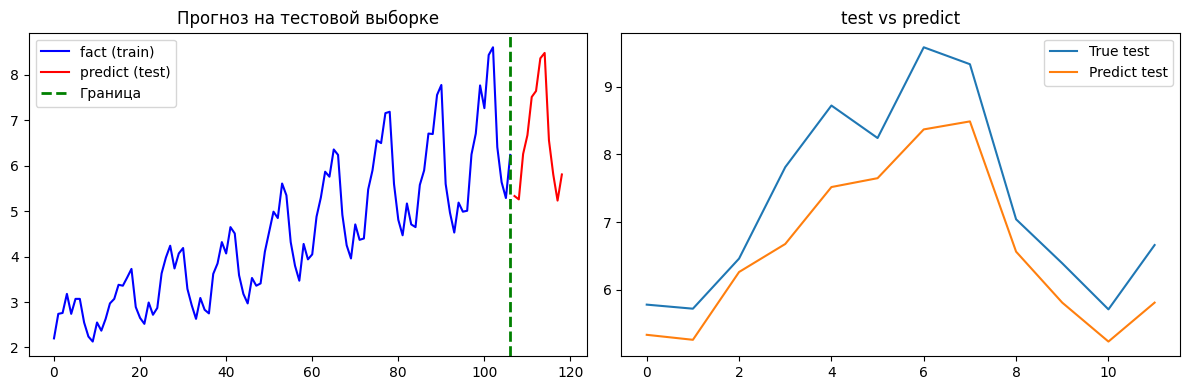

In [64]:
train_r2, test_r2 = model_predict_pytorch(rnn_model, x_train_t, y_train_t, x_test_t, y_test_t)

In [66]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        self.W_ih = nn.Parameter(torch.randn(4 * hidden_size, input_size) * 0.01)
        self.b_ih = nn.Parameter(torch.zeros(4 * hidden_size))
        self.W_hh = nn.Parameter(torch.randn(4 * hidden_size, hidden_size) * 0.01)
        self.b_hh = nn.Parameter(torch.zeros(4 * hidden_size))

        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()

    def forward(self, x, state):
        # x: (batch, input_size)
        # state: tuple (h_prev, c_prev) каждый размер (batch, hidden_size)
        h_prev, c_prev = state

        gates = x @ self.W_ih.t() + self.b_ih + h_prev @ self.W_hh.t() + self.b_hh

        i, f, g, o = gates.chunk(4, dim=1)
        i = self.sigmoid(i)   # input gate
        f = self.sigmoid(f)   # forget gate
        g = self.tanh(g)      # candidate cell
        o = self.sigmoid(o)   # output gate

        c_new = f * c_prev + i * g
        h_new = o * self.tanh(c_new)
        return h_new, (h_new, c_new)

class ManualLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.cell = LSTMCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.cell.hidden_size, device=x.device)
        c = torch.zeros(batch_size, self.cell.hidden_size, device=x.device)
        for t in range(seq_len):
            h, (h, c) = self.cell(x[:, t, :], (h, c))
        out = self.fc(h)
        return out

In [67]:
lstm_model = ManualLSTM(input_size=1, hidden_size=32, output_size=1)
lstm_model = train_model(lstm_model, x_train_t, y_train_t, x_test_t, y_test_t)

lstm_model.eval()
with torch.no_grad():
    train_pred = lstm_model(x_train_t).numpy()
    test_pred  = lstm_model(x_test_t).numpy()
    train_r2 = r2_score(y_train, train_pred)
    test_r2  = r2_score(y_test,  test_pred)
print(f"\nLSTM: R^2 train = {train_r2:.4f}, R^2 test = {test_r2:.4f}")

Epoch 20: train_loss=0.767247, train_r2=0.4596, val_r2=-0.7541
Epoch 40: train_loss=0.409585, train_r2=0.8351, val_r2=0.0246
Epoch 60: train_loss=0.224854, train_r2=0.9169, val_r2=0.4043
Epoch 80: train_loss=0.138628, train_r2=0.9487, val_r2=0.5692
Epoch 100: train_loss=0.109295, train_r2=0.9598, val_r2=0.6099
Early stopping at epoch 117 (val_r2 = 0.5959)

LSTM: R^2 train = 0.9584, R^2 test = 0.6095


----------------
MSE loss (train / test): 0.095742 \ 0.710170
R^2 метрика (train \ test): 0.9584 \ 0.6095
----------------


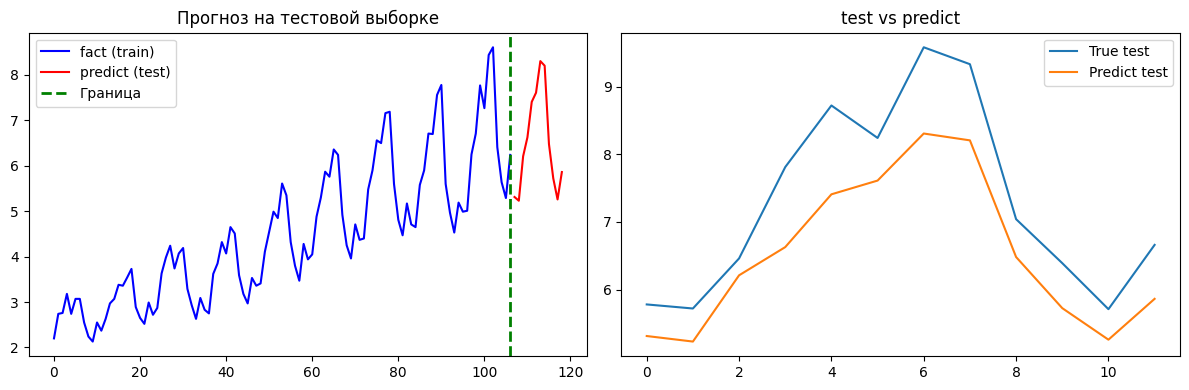

In [68]:
train_r2, test_r2 = model_predict_pytorch(lstm_model, x_train_t, y_train_t, x_test_t, y_test_t)

In [69]:
class GRUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        # Веса для reset gate (r)
        self.W_ir = nn.Parameter(torch.randn(hidden_size, input_size) * 0.01)
        self.b_ir = nn.Parameter(torch.zeros(hidden_size))
        self.W_hr = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_hr = nn.Parameter(torch.zeros(hidden_size))

        # Веса для update gate (z)
        self.W_iz = nn.Parameter(torch.randn(hidden_size, input_size) * 0.01)
        self.b_iz = nn.Parameter(torch.zeros(hidden_size))
        self.W_hz = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_hz = nn.Parameter(torch.zeros(hidden_size))

        # Веса для кандидата (n)
        self.W_in = nn.Parameter(torch.randn(hidden_size, input_size) * 0.01)
        self.b_in = nn.Parameter(torch.zeros(hidden_size))
        self.W_hn = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_hn = nn.Parameter(torch.zeros(hidden_size))

        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()

    def forward(self, x, h_prev):

        # Reset gate
        r = self.sigmoid(x @ self.W_ir.t() + self.b_ir + h_prev @ self.W_hr.t() + self.b_hr)
        # Update gate
        z = self.sigmoid(x @ self.W_iz.t() + self.b_iz + h_prev @ self.W_hz.t() + self.b_hz)
        # Candidate hidden state
        n = self.tanh(x @ self.W_in.t() + self.b_in + r * (h_prev @ self.W_hn.t() + self.b_hn))
        # New hidden state
        h_new = (1 - z) * n + z * h_prev
        return h_new

class ManualGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.cell = GRUCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.cell.hidden_size, device=x.device)
        for t in range(seq_len):
            h = self.cell(x[:, t, :], h)
        out = self.fc(h) 
        return out

Epoch 20: train_loss=0.504582, train_r2=0.7075, val_r2=-0.3124
Epoch 40: train_loss=0.205588, train_r2=0.9254, val_r2=0.3546
Epoch 60: train_loss=0.153330, train_r2=0.9460, val_r2=0.5222
Epoch 80: train_loss=0.136751, train_r2=0.9518, val_r2=0.5909
Epoch 100: train_loss=0.128842, train_r2=0.9543, val_r2=0.6288
Epoch 120: train_loss=0.124055, train_r2=0.9557, val_r2=0.6494
Epoch 140: train_loss=0.120828, train_r2=0.9568, val_r2=0.6623
Epoch 160: train_loss=0.117105, train_r2=0.9584, val_r2=0.6708
Epoch 180: train_loss=0.112226, train_r2=0.9606, val_r2=0.6782
Epoch 200: train_loss=0.108427, train_r2=0.9623, val_r2=0.6852
Epoch 220: train_loss=0.104182, train_r2=0.9642, val_r2=0.6875
Early stopping at epoch 234 (val_r2 = 0.6878)
----------------
MSE loss (train / test): 0.083797 \ 0.568635
R^2 метрика (train \ test): 0.9636 \ 0.6873
----------------


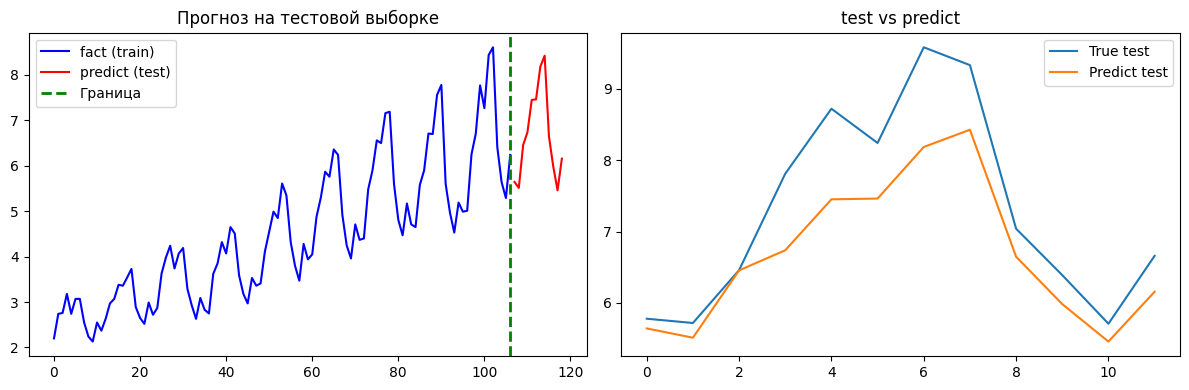

In [72]:
gru_model = ManualGRU(input_size=1, hidden_size=32, output_size=1)
gru_model = train_model(gru_model, x_train_t, y_train_t, x_test_t, y_test_t)
train_r2, test_r2 = model_predict_pytorch(gru_model, x_train_t, y_train_t, x_test_t, y_test_t)